In [1]:
# import sys
# import xarray as xr
# import numpy as np
# import matplotlib.pyplot as plt
# import os

# # download data to Colab
# for ens in np.arange(1,11):
#     os.system('wget -O HW5_ens'+str(ens).zfill(2)+'.nc https://zenodo.org/record/7384713/files/HW5_ens'+str(ens).zfill(2)+'.nc?download=1')


sh: wget: command not found
sh: wget: command not found
sh: wget: command not found
sh: wget: command not found
sh: wget: command not found
sh: wget: command not found
sh: wget: command not found
sh: wget: command not found
sh: wget: command not found
sh: wget: command not found


In [ ]:
import os
import requests
import sys
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os

# Function to download a file using requests
def download_file(url, filename):
    response = requests.get(url, stream=True)
    if response.status_code == 200:
        with open(filename, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
    else:
        print(f"Failed to download {filename}. Status code: {response.status_code}")

# Download data
for ens in range(1, 11):
    filename = f'HW5_ens{str(ens).zfill(2)}.nc'
    url = f'https://zenodo.org/record/7384713/files/{filename}?download=1'
    download_file(url, filename)

In [ ]:
!pip install netCDF4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 39.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 62.3 MB/s eta 0:00:00


In [4]:
# the nc file has 4 dimensions: initial time (time), lead time (step), latitude, longitude
# ens01 indicates the first ensemble member and ens02 is the second ensemble member
import netCDF4


In [ ]:
gh = np.zeros((10,8,47,121,240)) # number of ensemble, initialization time, forecast lead, lat, lon
for i in range(1,11):
    # fp     = '/content/HW5_ens'+str(i).zfill(2)+'.nc'
    fp     = 'HW5_ens'+str(i).zfill(2)+'.nc'
    nc     = netCDF4.Dataset(fp)
    gh[i-1,] = nc['gh'][:]
y = nc['latitude'][:]
x = nc['longitude'][:]
lon,lat = np.meshgrid(x,y)

In [7]:
gh_weighted = gh * np.cos(lat/180*np.pi)**0.5
gh_weighted = np.reshape(gh_weighted,[int(np.size(gh_weighted)/(np.size(y)*np.size(x))),int(np.size(y)*np.size(x))])

In [8]:
import numpy as np
from sklearn.decomposition import PCA
modes = 100
pca = PCA(n_components=modes)
pca.fit(gh_weighted)

PCA(n_components=100)

In [10]:
# dimension reduction
# derive EOF pattern (spatial structure) and principal components (time series)
EOF     = np.reshape(pca.components_,[modes,np.size(y),np.size(x)])
pcs     = np.dot(gh_weighted,pca.components_.transpose())
pcs_std = np.reshape(np.std(pcs,axis=0),[100,1])
pcs     = pcs/np.std(pcs_std,axis=0)
pcs     = np.reshape(pcs,[10,8,47,modes])


In [30]:
import xarray as xr

# Create DataArrays
EOF_da = xr.DataArray(EOF, dims=['mode', 'y', 'x'], name='EOF')
pcs_da = xr.DataArray(pcs, dims=['ensemble', 'init', 'lead', 'mode'], name='pcs')
pcs_std_da = xr.DataArray(pcs_std, dims=['mode', '1'], name='pcs_std')

# Create a Dataset to store them together
ds = xr.Dataset({'EOF': EOF_da, 'pcs': pcs_da, 'pcs_std': pcs_std_da})

# Save to a NetCDF file
ds.to_netcdf('dimension_reduction_results.nc')

# To load them later:
# ds_loaded = xr.open_dataset('dimension_reduction_results.nc')

In [31]:
import xarray as xr

# Load the NetCDF file
ds_loaded = xr.open_dataset('dimension_reduction_results.nc')

# Access the DataArrays from the loaded Dataset
EOF_loaded = ds_loaded['EOF']
pcs_loaded = ds_loaded['pcs']
pcs_std_loaded = ds_loaded['pcs_std']

# Print some basic information to verify the data
print(ds_loaded)

# Optionally, inspect a specific DataArray
print(EOF_loaded)

<xarray.Dataset>
Dimensions:  (mode: 100, y: 121, x: 240, time: 10, ensemble: 8, index: 47, 1: 1)
Dimensions without coordinates: mode, y, x, time, ensemble, index, 1
Data variables:
    EOF      (mode, y, x) float64 ...
    pcs      (time, ensemble, index, mode) float64 ...
    pcs_std  (mode, 1) float64 ...
<xarray.DataArray 'EOF' (mode: 100, y: 121, x: 240)>
[2904000 values with dtype=float64]
Dimensions without coordinates: mode, y, x


In [11]:
# calculate deviation from ensemble mean
gh_prime  = pcs - pcs.mean(axis=0)

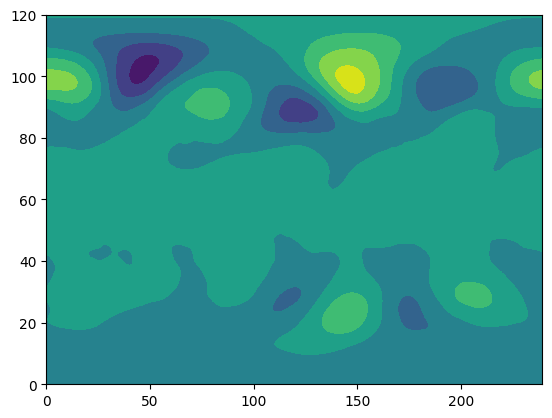

In [21]:
# plt.figure()
# plt.contourf(EOF)
plt.figure()
plt.contourf(EOF[4,::-1,:])
# EOF.shape

In [22]:
modes       = 100
var_X1_sum  = np.zeros((modes,modes))
count       = 0
for cases in range(8):
    for i in range(30,47):
        X1         = np.reshape(gh_prime[:,cases,i,],[10,modes])
        sigma_clim = X1.transpose().dot(X1)
        var_X1_sum = (var_X1_sum*count + sigma_clim)/(count+1)
        count      = count+1

count       = 0
var_sum     = np.zeros((modes,modes))
for i in range(47):
    X2      = np.reshape(gh_prime[:,0,i,],[10,modes])
    var_sum = (var_sum*count + var_X1_sum-X2.transpose().dot(X2))/(count+1)
    count   = count+1

641.2402345596014
77.81993116625918


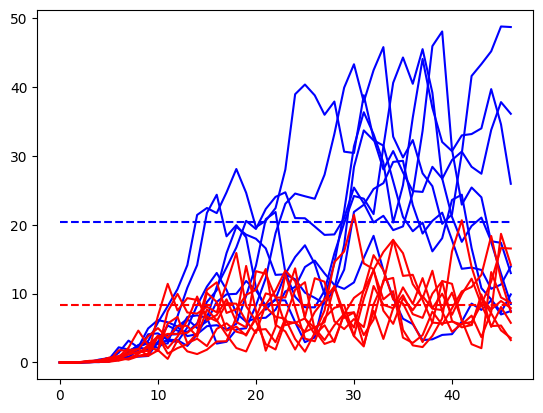

In [23]:
v,w     = np.linalg.eig(var_sum.dot(np.linalg.inv(var_X1_sum)))
idx     = v.argsort()[::-1]
v       = v[idx]
w       = w[:,idx]

pcs_tau = np.reshape(gh_prime,[10*8,47,100]).dot(w)
pcs_tau = np.reshape(pcs_tau,[10,8,47,100])

mode1 = 0
mode2 = 50
plt.figure()
plt.plot((pcs_tau.var(axis=0))[:,:,mode1].T,'b')
plt.plot(np.arange(0,47),np.ones([47,1])*(pcs_tau.var(axis=0))[:,46,mode1].mean(axis=0),'b--')

print(np.sum((pcs_tau.var(axis=0))[:,46,mode1].mean(axis=0)-(pcs_tau.var(axis=0))[0,:,mode1]))


plt.plot((pcs_tau.var(axis=0))[:,:,mode2].T,'r')
plt.plot(np.arange(0,47),np.ones([47,1])*(pcs_tau.var(axis=0))[:,46,mode2].mean(axis=0),'r--')
print(np.sum((pcs_tau.var(axis=0))[0,46,mode2]-(pcs_tau.var(axis=0))[0,:,mode2]))




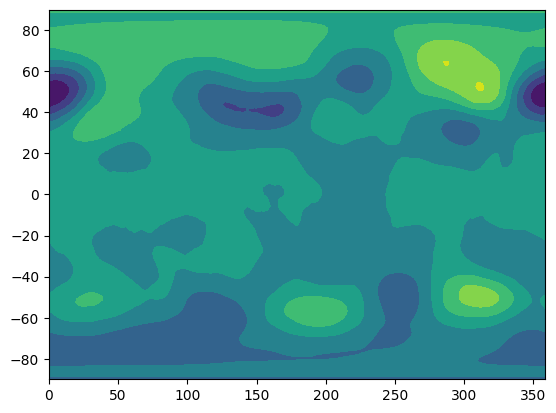

In [29]:
predictable_component = w[:,0].T.dot(pca.components_)
predictable_component = np.reshape(predictable_component,[np.size(y),np.size(x)])
plt.figure()
plt.contourf(lon,lat,predictable_component)